# Subgroups, Intersectionality, and Uncertainty

Objective: Use the real Adult Census Income dataset to explain why subgroup size and uncertainty matter when interpreting fairness metrics.

Based on:
- Adult Census Income dataset from UCI, accessed through HuggingFace
- Buolamwini and Gebru (2018), "Gender Shades"
- Kearns, Neel, Roth, and Wu (2018), "Preventing Fairness Gerrymandering"

## What you will do

1. Compare overall, single-axis, and intersectional subgroup metrics.
2. Explain why small subgroup sample sizes make metrics harder to interpret.
3. Compute a bootstrap interval for a subgroup gap.
4. Write a short documentation note for a fairness audit.

## Background

Overall accuracy can hide subgroup-specific harms. A model can look acceptable on average while performing worse for a smaller subgroup. This notebook uses `sex`, `race`, and `sex + race` groups to show why subgroup auditing needs both metric values and uncertainty context.


In [1]:
# Setup: import libraries for this fairness demo

import os  # controls a few dataset download settings
import numpy as np  # stores numbers and handles missing metric values
import pandas as pd  # stores data tables
import matplotlib.pyplot as plt  # makes simple charts
from datasets import load_dataset  # downloads datasets from HuggingFace
from sklearn.linear_model import LogisticRegression  # trains a simple classification model
from sklearn.metrics import accuracy_score  # measures the share of correct predictions
from sklearn.model_selection import train_test_split  # splits data into training and test rows

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"


## Step 1: Load the Dataset

We start by downloading the Adult Census Income dataset from HuggingFace. The original dataset comes from the UCI Machine Learning Repository.


In [2]:
# Download and inspect the Adult Census Income dataset

adult_dataset = load_dataset("scikit-learn/adult-census-income")
adult_raw = adult_dataset["train"].to_pandas()

print("Dataset source: scikit-learn/adult-census-income on HuggingFace")
print("Rows:", len(adult_raw))
print("Columns:", len(adult_raw.columns))

adult_raw.head()


Dataset source: scikit-learn/adult-census-income on HuggingFace
Rows: 32561
Columns: 15


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Step 2: Prepare the Dataset

The dataset has missing values written as `?`. We remove those rows for this beginner demo so the subgroup calculations are easier to read.


In [3]:
# Clean column names and create the prediction target

adult_data = adult_raw.copy()
adult_data.columns = adult_data.columns.str.replace(".", "_", regex=False)

for column_name in adult_data.columns:
    if adult_data[column_name].dtype == "object":
        adult_data[column_name] = adult_data[column_name].astype(str).str.strip()

adult_data = adult_data.replace("?", np.nan)
adult_data = adult_data.dropna().reset_index(drop=True)

adult_data["income_over_50k"] = 0
adult_data.loc[adult_data["income"].str.contains(">50K", regex=False), "income_over_50k"] = 1

print("Rows after dropping rows with unknown values:", len(adult_data))
print("Positive label means income is greater than 50K.")

adult_data["income_over_50k"].value_counts(normalize=True).rename("share")


Rows after dropping rows with unknown values: 30162
Positive label means income is greater than 50K.


income_over_50k
0    0.751078
1    0.248922
Name: share, dtype: float64

## Step 3: Train One Audit Model

The audit model excludes `sex` and `race` from the model features. We still use those columns in the test data to compute subgroup metrics.


In [4]:
# Train one audit model that excludes sex and race

train_data, test_data = train_test_split(
    adult_data,
    test_size=0.25,
    random_state=43,
    stratify=adult_data["income_over_50k"],
)

feature_columns = []
for column_name in adult_data.columns:
    if column_name != "income" and column_name != "income_over_50k" and column_name != "sex" and column_name != "race":
        feature_columns.append(column_name)

train_features = train_data[feature_columns].copy()
test_features = test_data[feature_columns].copy()

for column_name in feature_columns:
    if pd.api.types.is_numeric_dtype(train_features[column_name]):
        training_mean = train_features[column_name].mean()
        training_std = train_features[column_name].std()
        if training_std == 0:
            training_std = 1
        train_features[column_name] = (train_features[column_name] - training_mean) / training_std
        test_features[column_name] = (test_features[column_name] - training_mean) / training_std

train_encoded = pd.get_dummies(train_features)
test_encoded = pd.get_dummies(test_features)
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

training_labels = train_data["income_over_50k"]
test_labels = test_data["income_over_50k"]

audit_model = LogisticRegression(max_iter=1000, class_weight="balanced")
audit_model.fit(train_encoded, training_labels)
model_predictions = audit_model.predict(test_encoded)
model_scores = audit_model.predict_proba(test_encoded)[:, 1]

audit_results = test_data[["sex", "race", "income_over_50k"]].copy()
audit_results["prediction"] = model_predictions
audit_results["score"] = model_scores

print("Overall accuracy:", round(accuracy_score(test_labels, model_predictions), 3))
audit_results.head()


Overall accuracy: 0.802


,sex,race,income_over_50k,prediction,score
11091,Male,Asian-Pac-Islander,0,1,0.515908
19608,Female,White,0,0,0.318492
9536,Male,White,0,0,0.205772
21172,Male,Asian-Pac-Islander,0,0,0.002824
2607,Male,Asian-Pac-Islander,1,1,0.991467


## Step 4: Compare Overall and Subgroup Metrics

Now we compute group metrics three ways: overall, by `sex`, by `race`, and by the intersection of `sex` and `race`.


In [5]:
# Compute overall, single-axis, and intersectional metrics

metric_rows = []
grouping_plans = [
    {"group_type": "overall", "group_columns": []},
    {"group_type": "sex", "group_columns": ["sex"]},
    {"group_type": "race", "group_columns": ["race"]},
    {"group_type": "sex_and_race", "group_columns": ["sex", "race"]},
]

for grouping_plan in grouping_plans:
    group_type = grouping_plan["group_type"]
    group_columns = grouping_plan["group_columns"]

    if len(group_columns) == 0:
        grouped_results = [("all rows", audit_results)]
    else:
        if len(group_columns) == 1:
            grouped_results = audit_results.groupby(group_columns[0])
        else:
            grouped_results = audit_results.groupby(group_columns)

    for group_name, group_rows in grouped_results:
        if isinstance(group_name, tuple):
            readable_group_name = " + ".join(group_name)
        else:
            readable_group_name = str(group_name)

        true_positive_count = 0
        false_positive_count = 0
        true_negative_count = 0
        false_negative_count = 0

        for row_number, prediction_row in group_rows.iterrows():
            true_label = prediction_row["income_over_50k"]
            predicted_label = prediction_row["prediction"]

            if true_label == 1 and predicted_label == 1:
                true_positive_count = true_positive_count + 1
            if true_label == 0 and predicted_label == 1:
                false_positive_count = false_positive_count + 1
            if true_label == 0 and predicted_label == 0:
                true_negative_count = true_negative_count + 1
            if true_label == 1 and predicted_label == 0:
                false_negative_count = false_negative_count + 1

        group_size = len(group_rows)
        actual_positive_count = true_positive_count + false_negative_count
        actual_negative_count = false_positive_count + true_negative_count
        selection_rate = (true_positive_count + false_positive_count) / group_size
        accuracy = (true_positive_count + true_negative_count) / group_size

        if actual_positive_count == 0:
            true_positive_rate = np.nan
            false_negative_rate = np.nan
        else:
            true_positive_rate = true_positive_count / actual_positive_count
            false_negative_rate = false_negative_count / actual_positive_count

        if actual_negative_count == 0:
            false_positive_rate = np.nan
        else:
            false_positive_rate = false_positive_count / actual_negative_count

        metric_rows.append({
            "group_type": group_type,
            "group": readable_group_name,
            "n": group_size,
            "TP": true_positive_count,
            "FP": false_positive_count,
            "TN": true_negative_count,
            "FN": false_negative_count,
            "actual_positive_count": actual_positive_count,
            "selection_rate": selection_rate,
            "TPR": true_positive_rate,
            "FPR": false_positive_rate,
            "FNR": false_negative_rate,
            "accuracy": accuracy,
        })

subgroup_metrics = pd.DataFrame(metric_rows)
subgroup_metrics.round(3)


,group_type,group,n,TP,FP,TN,FN,actual_positive_count,selection_rate,TPR,FPR,FNR,accuracy
0,overall,all rows,7541,1583,1197,4467,294,1877,0.369,0.843,0.211,0.157,0.802
1,sex,Female,2458,215,181,1991,71,286,0.161,0.752,0.083,0.248,0.897
2,sex,Male,5083,1368,1016,2476,223,1591,0.469,0.860,0.291,0.140,0.756
3,race,Amer-Indian-Eskimo,78,9,15,52,2,11,0.308,0.818,0.224,0.182,0.782
4,race,Asian-Pac-Islander,242,57,38,132,15,72,0.393,0.792,0.224,0.208,0.781
5,race,Black,737,81,65,570,21,102,0.198,0.794,0.102,0.206,0.883
6,race,Other,63,3,5,53,2,5,0.127,0.600,0.086,0.400,0.889
7,race,White,6421,1433,1074,3660,254,1687,0.390,0.849,0.227,0.151,0.793
8,sex_and_race,Female + Amer-Indian-Eskimo,33,4,2,26,1,5,0.182,0.800,0.071,0.200,0.909
9,sex_and_race,Female + Asian-Pac-Islander,75,5,8,55,7,12,0.173,0.417,0.127,0.583,0.800


## Step 5: Inspect Stable Intersectional Groups

Small groups can have noisy metrics. The table shows both `n` and `actual_positive_count`. For the ranked table below, we only keep intersectional groups with at least 20 actual positive examples. This avoids treating a very small denominator as if it were as stable as a large group.


In [6]:
# Sort stable intersectional groups by false negative rate

minimum_actual_positive_count = 20

intersectional_metrics = subgroup_metrics[subgroup_metrics["group_type"] == "sex_and_race"].copy()
stable_intersectional_metrics = intersectional_metrics[
    intersectional_metrics["actual_positive_count"] >= minimum_actual_positive_count
].copy()
stable_intersectional_metrics = stable_intersectional_metrics.sort_values("FNR", ascending=False)

stable_intersectional_metrics[["group", "n", "actual_positive_count", "selection_rate", "TPR", "FPR", "FNR", "accuracy"]].round(3)


,group,n,actual_positive_count,selection_rate,TPR,FPR,FNR,accuracy
10,Female + Black,359,24,0.100,0.667,0.060,0.333,0.922
12,Female + White,1968,245,0.173,0.776,0.088,0.224,0.895
15,Male + Black,378,78,0.291,0.833,0.150,0.167,0.847
17,Male + White,4453,1442,0.486,0.862,0.307,0.138,0.748
14,Male + Asian-Pac-Islander,167,60,0.491,0.867,0.280,0.133,0.772


## Step 6: Bootstrap the Stable FNR Gap

A bootstrap interval is an uncertainty range made by resampling rows with replacement. Here we bootstrap the FNR gap only across the stable intersectional groups from Step 5. This keeps the uncertainty check focused on groups with enough actual positive examples to support the FNR calculation.


In [7]:
# Bootstrap the stable intersectional FNR gap

eligible_group_names = []
for row_number, metric_row in stable_intersectional_metrics.iterrows():
    eligible_group_names.append(metric_row["group"])

bootstrap_random_generator = np.random.default_rng(123)
bootstrap_rows = []

for bootstrap_round in range(200):
    sampled_positions = bootstrap_random_generator.integers(0, len(audit_results), len(audit_results))
    sampled_results = audit_results.iloc[sampled_positions]
    sampled_metric_rows = []

    for group_name, group_rows in sampled_results.groupby(["sex", "race"]):
        readable_group_name = " + ".join(group_name)
        group_is_eligible = False

        for eligible_group_name in eligible_group_names:
            if readable_group_name == eligible_group_name:
                group_is_eligible = True

        if group_is_eligible:
            true_positive_count = 0
            false_negative_count = 0

            for row_number, prediction_row in group_rows.iterrows():
                true_label = prediction_row["income_over_50k"]
                predicted_label = prediction_row["prediction"]

                if true_label == 1 and predicted_label == 1:
                    true_positive_count = true_positive_count + 1
                if true_label == 1 and predicted_label == 0:
                    false_negative_count = false_negative_count + 1

            actual_positive_count = true_positive_count + false_negative_count

            if actual_positive_count == 0:
                false_negative_rate = np.nan
            else:
                false_negative_rate = false_negative_count / actual_positive_count

            sampled_metric_rows.append({
                "group": readable_group_name,
                "FNR": false_negative_rate,
            })

    sampled_metric_table = pd.DataFrame(sampled_metric_rows).dropna()
    false_negative_rate_gap = sampled_metric_table["FNR"].max() - sampled_metric_table["FNR"].min()
    bootstrap_rows.append({
        "bootstrap_round": bootstrap_round,
        "stable_intersectional_FNR_gap": false_negative_rate_gap,
    })

bootstrap_results = pd.DataFrame(bootstrap_rows)
bootstrap_interval = pd.DataFrame({
    "metric": ["stable_intersectional_FNR_gap"],
    "observed_gap": [stable_intersectional_metrics["FNR"].max() - stable_intersectional_metrics["FNR"].min()],
    "bootstrap_low_2_5_percent": [bootstrap_results["stable_intersectional_FNR_gap"].quantile(0.025)],
    "bootstrap_high_97_5_percent": [bootstrap_results["stable_intersectional_FNR_gap"].quantile(0.975)],
})

bootstrap_interval.round(3)


,metric,observed_gap,bootstrap_low_2_5_percent,bootstrap_high_97_5_percent
0,stable_intersectional_FNR_gap,0.2,0.086,0.393


## Step 7: Visualize Uncertainty

The histogram shows how much the intersectional FNR gap moves across bootstrap samples.


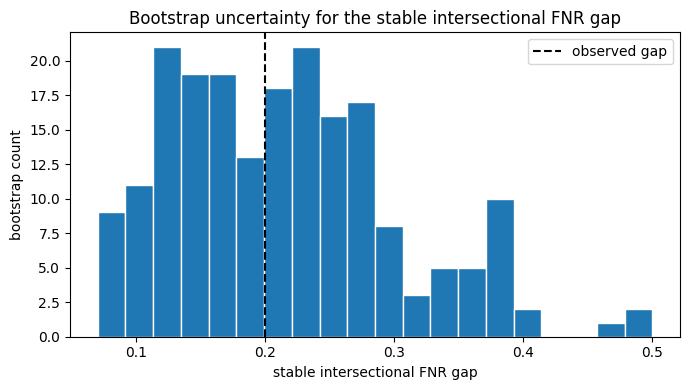

In [8]:
# Visualize the bootstrap distribution

plt.figure(figsize=(7, 4))
plt.hist(bootstrap_results["stable_intersectional_FNR_gap"], bins=20, edgecolor="white")
plt.axvline(bootstrap_interval.loc[0, "observed_gap"], color="black", linestyle="--", label="observed gap")
plt.xlabel("stable intersectional FNR gap")
plt.ylabel("bootstrap count")
plt.title("Bootstrap uncertainty for the stable intersectional FNR gap")
plt.legend()
plt.tight_layout()
plt.show()


## Step 8: Document the Audit

A result table is easier to misuse when it does not say what data, model, metric, and limits were used.


In [9]:
# Create a short documentation card for the audit

documentation_card = pd.DataFrame({
    "field": [
        "Dataset",
        "Model",
        "Excluded features",
        "Positive label",
        "Main subgroup check",
        "Uncertainty check",
        "Main limitation",
    ],
    "classroom_note": [
        "Adult Census Income from HuggingFace",
        "Logistic regression classifier",
        "sex and race were excluded from model features",
        "income_over_50k equals 1",
        "sex, race, and sex by race metrics",
        "bootstrap interval for stable intersectional FNR gap",
        "this is a teaching audit, not a deployment decision",
    ],
})

documentation_card


,field,classroom_note
0,Dataset,Adult Census Income from HuggingFace
1,Model,Logistic regression classifier
2,Excluded features,sex and race were excluded from model features
3,Positive label,income_over_50k equals 1
4,Main subgroup check,"sex, race, and sex by race metrics"
5,Uncertainty check,bootstrap interval for stable intersectional F...
6,Main limitation,"this is a teaching audit, not a deployment dec..."


## References

- Adult Census Income dataset on HuggingFace: https://huggingface.co/datasets/scikit-learn/adult-census-income
- Becker, B., & Kohavi, R. (1996). Adult [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20
- Buolamwini, J., & Gebru, T. (2018). Gender Shades: Intersectional Accuracy Disparities in Commercial Gender Classification. Proceedings of Machine Learning Research, 81, 77-91. https://proceedings.mlr.press/v81/buolamwini18a.html
- Kearns, M., Neel, S., Roth, A., & Wu, S. (2018). Preventing Fairness Gerrymandering: Auditing and Learning for Subgroup Fairness. Proceedings of the 35th International Conference on Machine Learning. https://proceedings.mlr.press/v80/kearns18a.html

## Summary

You loaded a real dataset, compared overall and subgroup metrics, inspected stable intersectional groups, and used a bootstrap interval to show uncertainty.
